# 01 Import libraries

In [47]:
import numpy as np
import torch

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cpu


In [48]:
import pandas as pd

In [49]:
import importlib

In [50]:
%reload_ext autoreload
%autoreload 2

In [51]:
import lib
importlib.reload(lib)

<module 'lib' from 'c:\\Users\\dongq\\OneDrive\\Desktop\\project\\lib\\__init__.py'>

In [52]:
from lib.lsp.learn_solution_path import learn_solution_path_high_dim
from lib.fast_tensor_data_loader import FastTensorDataLoader

# 02 Instantiate dataset

In [53]:
# file path
decomp_cov_df = pd.read_csv('decomp_cov.csv')
mean_df = pd.read_csv('mean.csv')

In [54]:
decomp_cov_np = np.array(decomp_cov_df)
mean_np = np.array(mean_df).squeeze()

In [55]:
decomp_cov = torch.tensor(decomp_cov_np, dtype=torch.float32)
mean = torch.tensor(mean_np, dtype=torch.float32)

In [56]:
decomp_cov

tensor([[ 3.8584,  4.6557,  4.0503,  4.7056,  3.3298,  3.4872,  3.2121,  2.7176,
          2.7919,  3.9016],
        [ 0.0000,  9.6246,  1.4167,  1.5061,  2.6207,  0.6535,  2.1278,  0.8926,
         -0.1126,  1.8297],
        [ 0.0000,  0.0000,  2.6853,  2.6613,  1.4872,  1.3278,  1.2272,  1.4394,
          0.4031,  2.2804],
        [ 0.0000,  0.0000,  0.0000,  6.7527, -0.6083,  0.5163, -0.4300, -0.2296,
         -0.1087,  0.6784],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  3.0578,  0.4449,  1.4199,  0.8157,
          0.1635,  0.2507],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  2.9848,  0.2056,  0.2594,
         -0.0997,  0.5166],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  2.2011,  0.7656,
          0.1802,  0.1505],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  2.6989,
         -0.2101,  0.1462],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          3.0994, -0.2774],
        [ 0.0000,  

In [57]:
# full gradient descent uses all data points
GD_data_loader = FastTensorDataLoader(decomp_cov, mean, batch_size=len(decomp_cov), shuffle=False, )
# test data
test_data_loader = FastTensorDataLoader(decomp_cov, mean, batch_size=len(decomp_cov), shuffle=False, )

In [58]:
dim_lambda = 12
lam_max_high_dim = np.ones(dim_lambda)
lam_min_high_dim = np.zeros(dim_lambda)
lam_min_high_dim[2:] = -2
lam_min_high_dim[0] = .2
lam_max_high_dim[2:] = 2
input_dim = decomp_cov.shape[1]

In [59]:
lam_min_high_dim

array([ 0.2,  0. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. , -2. ,
       -2. ])

In [60]:
lam_max_high_dim

array([1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

# 03 Define the Basis Generator

In [61]:
def taylor(lam, k):
    taylor_terms = np.append(np.ones(1), lam)
    for i in range(k):
        taylor_terms = np.append(taylor_terms, lam * (lam[0]**(i+1)))
    return taylor_terms

In [62]:
test = taylor(lam_min_high_dim, 3)
test

array([ 1.0e+00,  2.0e-01,  0.0e+00, -2.0e+00, -2.0e+00, -2.0e+00,
       -2.0e+00, -2.0e+00, -2.0e+00, -2.0e+00, -2.0e+00, -2.0e+00,
       -2.0e+00,  4.0e-02,  0.0e+00, -4.0e-01, -4.0e-01, -4.0e-01,
       -4.0e-01, -4.0e-01, -4.0e-01, -4.0e-01, -4.0e-01, -4.0e-01,
       -4.0e-01,  8.0e-03,  0.0e+00, -8.0e-02, -8.0e-02, -8.0e-02,
       -8.0e-02, -8.0e-02, -8.0e-02, -8.0e-02, -8.0e-02, -8.0e-02,
       -8.0e-02,  1.6e-03,  0.0e+00, -1.6e-02, -1.6e-02, -1.6e-02,
       -1.6e-02, -1.6e-02, -1.6e-02, -1.6e-02, -1.6e-02, -1.6e-02,
       -1.6e-02])

In [63]:
k = 3

In [64]:
basis_dim = (k+1) * len(lam_min_high_dim)+1
init_lr = .1

In [65]:
basis_dim

49

In [66]:
def taylor_expansion(lam, basis_dim, device='cpu'):
    vec = torch.tensor(taylor(lam, k), dtype=torch.float32)
    return vec.to(device)

In [67]:
phi_lam = taylor_expansion

# 04 Define the Loss Function

In [68]:
from numpy.linalg import inv

when lam_1/lam_2 = 1

In [69]:
inv(decomp_cov_np) @ mean_np /2 *5

array([-1.64057426, -0.05696513, -1.95674072,  0.26509981,  0.52782249,
       -0.02529369,  0.97657385,  0.82896155,  0.73344576,  1.50473187])

In [70]:
# alpha = .1

In [71]:
# # balance expected return, risk, and diversification
# # constraint is that sum of model weight should be 1. We achieve this by setting the first term of weight
# # to equal (1- sum of remaining terms of weight)
# def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
#     # compute predicted y_hat
#     n = decomp_cov.shape[1]
#     # no need to transform lambdas
#     theta = model(hyper_params, device)
#     risk = torch.mm(decomp_cov, theta.view(-1, 1))
#     exp_rtrn = torch.mm(mean.view(-1, 1).T, theta.view(-1, 1))
#     cost = (theta - torch.tensor(hyper_params[2:], dtype=torch.float32)).norm(p=2)**2

#     # input hyperparameter lam is a 2-d array
#     loss = hyper_params[0] * risk.norm(p=2)**2 - hyper_params[1] * exp_rtrn + cost + alpha * ((model.linear.weight[1:, :]).norm(p=2)**2)


#     return loss

$\gamma$-penalized training loss

In [72]:
# balance expected return, risk, and diversification
# constraint is that sum of model weight should be 1. We achieve this by setting the first term of weight
# to equal (1- sum of remaining terms of weight)
def allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device="cpu"):
    # compute predicted y_hat
    n = decomp_cov.shape[1]
    # no need to transform lambdas
    theta = model(hyper_params, device)
    risk = torch.mm(decomp_cov, theta.view(-1, 1))
    exp_rtrn = torch.mm(mean.view(-1, 1).T, theta.view(-1, 1))
    cost = (theta - torch.tensor(hyper_params[2:], dtype=torch.float32)).norm(p=2)**2

    # input hyperparameter lam is a 2-d array
    loss = hyper_params[0] * risk.norm(p=2)**2 - hyper_params[1] * exp_rtrn + cost + gamma * ((model.linear.weight[1:, :]).norm(p=2)**2)


    return loss

In [73]:
# balance expected return, risk, and diversification
# constraint is that sum of model weight should be 1. We achieve this by setting the first term of weight
# to equal (1- sum of remaining terms of weight)
def allocation_cost_val(hyper_params, decomp_cov, mean, model, device="cpu"):
    # compute predicted y_hat
    n = decomp_cov.shape[1]
    # no need to transform lambdas
    theta = model(hyper_params, device)
    risk = torch.mm(decomp_cov, theta.view(-1, 1))
    exp_rtrn = torch.mm(mean.view(-1, 1).T, theta.view(-1, 1))
    cost = (theta - torch.tensor(hyper_params[2:], dtype=torch.float32)).norm(p=2)**2

    # input hyperparameter lam is a 2-d array
    loss = hyper_params[0] * risk.norm(p=2)**2 - hyper_params[1] * exp_rtrn + cost



    return loss

# 03 Learn Solution Path of the ERM Problem with L-BFGS

In [74]:
def thresh_basis(basis_dim):
    return -1

In [75]:
from scipy.stats import uniform


np.random.seed(42)
train_set = []
for j in range(1000):
    samples = uniform.rvs(loc=0, scale=1, size=len(lam_min_high_dim))
    train_set.append(samples * (lam_max_high_dim - lam_min_high_dim) + lam_min_high_dim)

In [76]:
train_set[0]

array([ 0.4996321 ,  0.95071431,  0.92797577,  0.39463394, -1.37592544,
       -1.37602192, -1.76766555,  1.46470458,  0.40446005,  0.83229031,
       -1.91766202,  1.87963941])

In [77]:
np.random.seed(88)
val_set = []
for j in range(1000):
    samples = uniform.rvs(loc=0, scale=1, size=len(lam_min_high_dim))
    val_set.append(samples * (lam_max_high_dim - lam_min_high_dim) + lam_min_high_dim)

In [41]:
val_losses = []

In [42]:
train_losses = []

In [43]:
train_losses_reg = []

## $\gamma = 10$

In [44]:
gamma = 10 # regularization parameter

In [45]:
def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
    return allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device)

In [46]:
loss_fn_train = allocation_cost_train
loss_fn_val = allocation_cost_val

In [47]:
max_epochs = 15

In [48]:
np.random.seed(8675309)
torch.manual_seed(8675309)

loss_train, loss_val, loss_train_reg, weight = learn_solution_path_high_dim(input_dim, basis_dim, phi_lam, max_epochs,
                                                               GD_data_loader, test_data_loader, loss_fn_train, loss_fn_val,
                                                               lam_min_high_dim, lam_max_high_dim, init_lr=init_lr,
                                                               diminish=False, 
                                                               intercept=False, weighted_avg=False, thresh_basis=thresh_basis,
                                                            #    record_fctn=get_sup_error_lsp_2d,
                                                               record_frequency=-1, distribution='uniform',
                                                               opt_method='lbfgs',
                                                               device=device, trace_frequency=1)

--------approximate solution path for # function evaluation = 0 complete--------
# gradient call: 0	 average loss on training: 13.347564279019833
# gradient call: 0	 average loss on validation: 13.228360370635986
--------approximate solution path for # function evaluation = 20 complete--------
# gradient call: 1	 average loss on training: 11.675582927525044
# gradient call: 1	 average loss on validation: 11.587731583356858
--------approximate solution path for # function evaluation = 40 complete--------
# gradient call: 2	 average loss on training: 11.538160107910633
# gradient call: 2	 average loss on validation: 11.453195044517518
--------approximate solution path for # function evaluation = 60 complete--------
# gradient call: 3	 average loss on training: 11.541484327554702
# gradient call: 3	 average loss on validation: 11.457322970271111
--------approximate solution path for # function evaluation = 80 complete--------
# gradient call: 4	 average loss on training: 11.54979812550544

In [49]:
val_losses.append(loss_val)
train_losses.append(loss_train)
train_losses_reg.append(loss_train_reg)

## $\gamma = 1$

In [50]:
gamma = 1 # regularization parameter

In [51]:
def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
    return allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device)

In [52]:
loss_fn_train = allocation_cost_train
loss_fn_val = allocation_cost_val

In [53]:
max_epochs = 15

In [54]:
np.random.seed(8675309)
torch.manual_seed(8675309)

loss_train, loss_val, loss_train_reg, weight = learn_solution_path_high_dim(input_dim, basis_dim, phi_lam, max_epochs,
                                                               GD_data_loader, test_data_loader, loss_fn_train, loss_fn_val,
                                                               lam_min_high_dim, lam_max_high_dim, init_lr=init_lr,
                                                               diminish=False, 
                                                               intercept=False, weighted_avg=False, thresh_basis=thresh_basis,
                                                            #    record_fctn=get_sup_error_lsp_2d,
                                                               record_frequency=-1, distribution='uniform',
                                                               opt_method='lbfgs',
                                                               device=device, trace_frequency=1)

--------approximate solution path for # function evaluation = 0 complete--------
# gradient call: 0	 average loss on training: 13.347564279019833
# gradient call: 0	 average loss on validation: 13.228360370635986
--------approximate solution path for # function evaluation = 20 complete--------
# gradient call: 1	 average loss on training: 11.087791244745254
# gradient call: 1	 average loss on validation: 11.009037735462188
--------approximate solution path for # function evaluation = 40 complete--------
# gradient call: 2	 average loss on training: 10.84212235200405
# gradient call: 2	 average loss on validation: 10.7709992197752
--------approximate solution path for # function evaluation = 60 complete--------
# gradient call: 3	 average loss on training: 10.780602707386016
# gradient call: 3	 average loss on validation: 10.709693413496018
--------approximate solution path for # function evaluation = 80 complete--------
# gradient call: 4	 average loss on training: 10.787281621694564
#

In [55]:
val_losses.append(loss_val)
train_losses.append(loss_train)
train_losses_reg.append(loss_train_reg)

## $\gamma = .1$

In [56]:
gamma = .1 # regularization parameter

In [57]:
def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
    return allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device)

In [58]:
loss_fn_train = allocation_cost_train
loss_fn_val = allocation_cost_val

In [59]:
max_epochs = 15

In [60]:
np.random.seed(8675309)
torch.manual_seed(8675309)

loss_train, loss_val, loss_train_reg, weight = learn_solution_path_high_dim(input_dim, basis_dim, phi_lam, max_epochs,
                                                               GD_data_loader, test_data_loader, loss_fn_train, loss_fn_val,
                                                               lam_min_high_dim, lam_max_high_dim, init_lr=init_lr,
                                                               diminish=False, 
                                                               intercept=False, weighted_avg=False, thresh_basis=thresh_basis,
                                                            #    record_fctn=get_sup_error_lsp_2d,
                                                               record_frequency=-1, distribution='uniform',
                                                               opt_method='lbfgs',
                                                               device=device, trace_frequency=1)

--------approximate solution path for # function evaluation = 0 complete--------
# gradient call: 0	 average loss on training: 13.347564279019833
# gradient call: 0	 average loss on validation: 13.228360370635986
--------approximate solution path for # function evaluation = 20 complete--------
# gradient call: 1	 average loss on training: 11.024604936599731
# gradient call: 1	 average loss on validation: 10.946968261122704
--------approximate solution path for # function evaluation = 40 complete--------
# gradient call: 2	 average loss on training: 10.72942672097683
# gradient call: 2	 average loss on validation: 10.663442261695861
--------approximate solution path for # function evaluation = 60 complete--------
# gradient call: 3	 average loss on training: 10.603753296792506
# gradient call: 3	 average loss on validation: 10.534983707070351
--------approximate solution path for # function evaluation = 80 complete--------
# gradient call: 4	 average loss on training: 10.588029595911502

In [61]:
val_losses.append(loss_val)
train_losses.append(loss_train)
train_losses_reg.append(loss_train_reg)

## $\gamma = .01$

In [ ]:
gamma = .01 # regularization parameter

In [ ]:
def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
    return allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device)

In [64]:
loss_fn_train = allocation_cost_train
loss_fn_val = allocation_cost_val

In [65]:
max_epochs = 15

In [66]:
np.random.seed(8675309)
torch.manual_seed(8675309)

loss_train, loss_val, loss_train_reg, weight = learn_solution_path_high_dim(input_dim, basis_dim, phi_lam, max_epochs,
                                                               GD_data_loader, test_data_loader, loss_fn_train, loss_fn_val,
                                                               lam_min_high_dim, lam_max_high_dim, init_lr=init_lr,
                                                               diminish=False, 
                                                               intercept=False, weighted_avg=False, thresh_basis=thresh_basis,
                                                            #    record_fctn=get_sup_error_lsp_2d,
                                                               record_frequency=-1, distribution='uniform',
                                                               opt_method='lbfgs',
                                                               device=device, trace_frequency=1)

--------approximate solution path for # function evaluation = 0 complete--------
# gradient call: 0	 average loss on training: 13.347564279019833
# gradient call: 0	 average loss on validation: 13.228360370635986
--------approximate solution path for # function evaluation = 20 complete--------
# gradient call: 1	 average loss on training: 11.019226642131805
# gradient call: 1	 average loss on validation: 10.941697142839432
--------approximate solution path for # function evaluation = 40 complete--------
# gradient call: 2	 average loss on training: 10.722911886036396
# gradient call: 2	 average loss on validation: 10.657627702713013
--------approximate solution path for # function evaluation = 60 complete--------
# gradient call: 3	 average loss on training: 10.595100768744945
# gradient call: 3	 average loss on validation: 10.52596548640728
--------approximate solution path for # function evaluation = 80 complete--------
# gradient call: 4	 average loss on training: 10.577026624798775

In [67]:
val_losses.append(loss_val)
train_losses.append(loss_train)
train_losses_reg.append(loss_train_reg)

In [71]:
file_path = 'LSP_results_reg_high_dim_train_avg_loss.csv'

train_losses_df = pd.DataFrame(train_losses).transpose()

# Save the DataFrame to a CSV file
train_losses_df.to_csv(file_path, index=False) # index saves the number of epochs

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the DataFrame
df

,0,1,2,3
0,13.347564,13.347564,13.347564,13.347564
1,11.675583,11.087791,11.024605,11.019227
2,11.538160,10.842122,10.729427,10.722912
3,11.541484,10.780603,10.603753,10.595101
4,11.549798,10.787282,10.588030,10.577027
5,11.549354,10.790804,10.585494,10.570752
6,11.539773,10.787035,10.581991,10.562990
7,11.542211,10.783408,10.579334,10.554173
8,11.544571,10.785309,10.577996,10.548358
9,11.543195,10.785388,10.576933,10.544824


In [72]:
file_path = 'LSP_results_reg_high_dim_val_avg_loss.csv'

val_losses_df = pd.DataFrame(val_losses).transpose()

# Save the DataFrame to a CSV file
val_losses_df.to_csv(file_path, index=False) # index saves the number of epochs

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the DataFrame
df

,0,1,2,3
0,13.228360,13.228360,13.228360,13.228360
1,11.587732,11.009038,10.946968,10.941697
2,11.453195,10.770999,10.663442,10.657628
3,11.457323,10.709693,10.534984,10.525965
4,11.465650,10.716473,10.519923,10.509014
5,11.465103,10.719981,10.517821,10.503481
6,11.455629,10.716101,10.514294,10.495897
7,11.458227,10.712677,10.511532,10.486845
8,11.460587,10.714729,10.510249,10.481018
9,11.459193,10.714782,10.509237,10.477578


# Adaptively shrink $\gamma$

In [100]:
gamma_list = [10, 1, .1, .01] # regularization parameter

In [101]:
weight = None
adaptive_val_losses = []
adaptive_train_losses = []
breaks = []
curr_epoch = 0

for gamma in gamma_list:
    def allocation_cost_train(hyper_params, decomp_cov, mean, model, device="cpu"):
        return allocation_cost_reg(gamma, hyper_params, decomp_cov, mean, model, device)
    
    loss_fn_train = allocation_cost_train
    loss_fn_val = allocation_cost_val

    max_epochs = 10
    np.random.seed(8675309)
    torch.manual_seed(8675309)

    loss_train, loss_val, loss_train_reg, weight, epochs = learn_solution_path_high_dim(input_dim, basis_dim, phi_lam, max_epochs,
                                                               GD_data_loader, test_data_loader, loss_fn_train, loss_fn_val,
                                                               lam_min_high_dim, lam_max_high_dim, init_lr=init_lr,
                                                               diminish=False, init_weight=weight,
                                                               intercept=False, weighted_avg=False, thresh_basis=thresh_basis,
                                                            #    record_fctn=get_sup_error_lsp_2d,
                                                               record_frequency=-1, distribution='uniform',
                                                               opt_method='lbfgs',
                                                               device=device, trace_frequency=1)
    curr_epoch += epochs-1
    if len(adaptive_train_losses)>0:
        adaptive_val_losses.extend(loss_val[1:])
        adaptive_train_losses.extend(loss_train[1:])
    else:
        adaptive_val_losses.extend(loss_val)
        adaptive_train_losses.extend(loss_train)
    breaks.append(curr_epoch)

--------approximate solution path for # gradient calls = 0.0 complete--------
# gradient call: 0	 average loss on training: 13.347564279019833
# gradient call: 0	 average loss on validation: 13.228360370635986
--------approximate solution path for # gradient calls = 1.0 complete--------
# gradient call: 1	 average loss on training: 11.675582927525044
# gradient call: 1	 average loss on validation: 11.587731583356858
--------approximate solution path for # gradient calls = 2.0 complete--------
# gradient call: 2	 average loss on training: 11.538160107910633
# gradient call: 2	 average loss on validation: 11.453195044517518
--------approximate solution path for # gradient calls = 3.0 complete--------
# gradient call: 3	 average loss on training: 11.541484327554702
# gradient call: 3	 average loss on validation: 11.457322970271111
--------approximate solution path for # gradient calls = 0.0 complete--------
# gradient call: 0	 average loss on training: 11.549798125505447
# gradient call: 

In [102]:
breaks

[3, 6, 8, 9]

In [103]:
file_path = 'LSP_results_reg_high_dim_adaptive_train_loss.csv'

train_losses_df = pd.DataFrame(adaptive_train_losses)
# Save the DataFrame to a CSV file
train_losses_df.to_csv(file_path, index=False) # index saves the number of epochs

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the DataFrame
df

,0
0,13.347564
1,11.675583
2,11.538160
3,11.541484
4,10.925609
5,10.802744
6,10.787646
7,10.662272
8,10.599825
9,10.585318


In [104]:
file_path = 'LSP_results_reg_high_dim_adaptive_val_loss.csv'

val_losses_df = pd.DataFrame(adaptive_val_losses)

# Save the DataFrame to a CSV file
val_losses_df.to_csv(file_path, index=False) # index saves the number of epochs

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the DataFrame
df

,0
0,13.228360
1,11.587732
2,11.453195
3,11.457323
4,10.852610
5,10.732170
6,10.716768
7,10.595281
8,10.531313
9,10.517337


# Plot

Compare train/validation set performance. Optimality computed before in notebook `01 Generate ERM Optimality (high dimension)`

In [1]:
val_opt_loss = 10.414102515751397

In [2]:
train_opt_loss = 10.428659738259746

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [4]:
import math

In [25]:
csv_file_path = 'LSP_results_reg_high_dim_train_avg_loss.csv'
train_losses = pd.read_csv(csv_file_path).to_numpy().transpose()

In [42]:
csv_file_path = 'LSP_results_reg_high_dim_val_avg_loss.csv'
val_losses = pd.read_csv(csv_file_path).to_numpy().transpose()

In [107]:
csv_file_path = 'LSP_results_reg_high_dim_adaptive_train_loss.csv'
adaptive_train_loss = pd.read_csv(csv_file_path).to_numpy().transpose().squeeze()

In [108]:
csv_file_path = 'LSP_results_reg_high_dim_adaptive_val_loss.csv'
adaptive_val_loss = pd.read_csv(csv_file_path).to_numpy().transpose().squeeze()

In [109]:
breaks = [3, 6, 8, 9]

In [111]:
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\dongq\AppData\Local\Temp\ipykernel_19780\3137579198.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(train_losses[i])), train_losses[i], '--o', color=colors[i], linewidth=5, markersize=15, alpha=0.7, label=f'$\gamma$={math.pow(10,1-i)}')
C:\Users\dongq\AppData\Local\Temp\ipykernel_19780\3137579198.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(adaptive_train_loss)), adaptive_train_loss, '--o', color='tab:orange', linewidth=8, markersize=20, alpha=0.8, label=f'Adaptive $\gamma$')


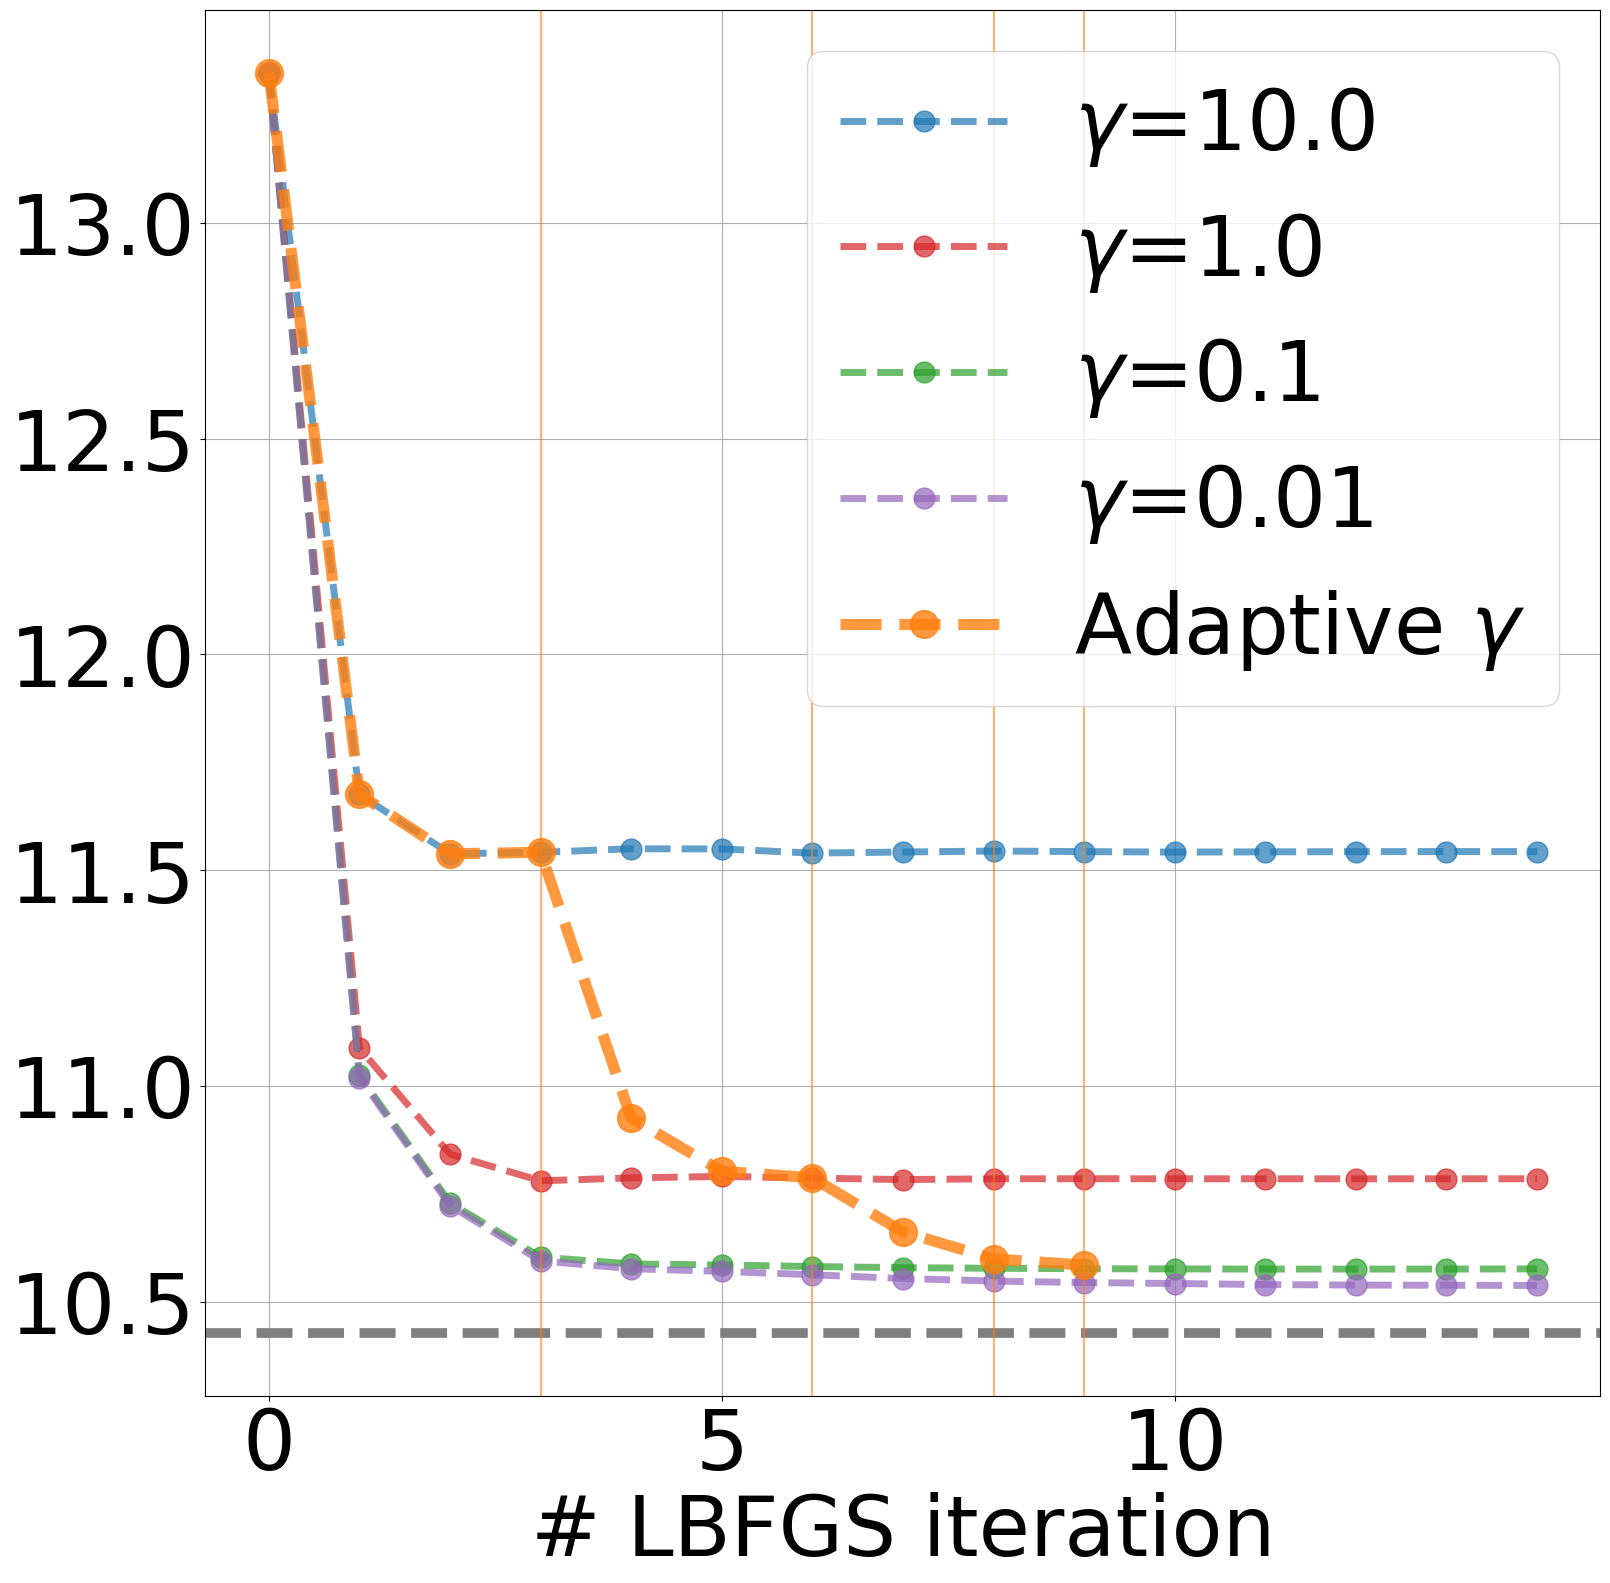

In [112]:
# plot result of our method:
plt.figure(figsize=(18,18))

plt.axhline(y = train_opt_loss, linestyle='--', linewidth=7, color='tab:grey')

for i in range(len(train_losses)):
    plt.plot(np.arange(len(train_losses[i])), train_losses[i], '--o', color=colors[i], linewidth=5, markersize=15, alpha=0.7, label=f'$\gamma$={math.pow(10,1-i)}')

plt.plot(np.arange(len(adaptive_train_loss)), adaptive_train_loss, '--o', color='tab:orange', linewidth=8, markersize=20, alpha=0.8, label=f'Adaptive $\gamma$')
for break_itr in breaks:
    plt.axvline(x = break_itr, color='tab:orange', alpha=0.6, zorder=2)
# Set global font size
mpl.rcParams['font.size'] = 60

font_size = 60

# plt.ylim(2.5, 3)

plt.xlabel(f'# LBFGS iteration', fontsize=font_size)
# plt.ylabel(f"$\\theta_i^*(\\lambda_2)$", fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\dongq\AppData\Local\Temp\ipykernel_19780\4208472939.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(val_losses[i])), val_losses[i], '--o', color=colors[i], linewidth=5, markersize=15, alpha=0.7, label=f'$\gamma$={math.pow(10,1-i)}')
C:\Users\dongq\AppData\Local\Temp\ipykernel_19780\4208472939.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(adaptive_val_loss)), adaptive_val_loss, '--o', color='tab:orange', linewidth=8, markersize=20, alpha=0.8, label=f'Adaptive $\gamma$')


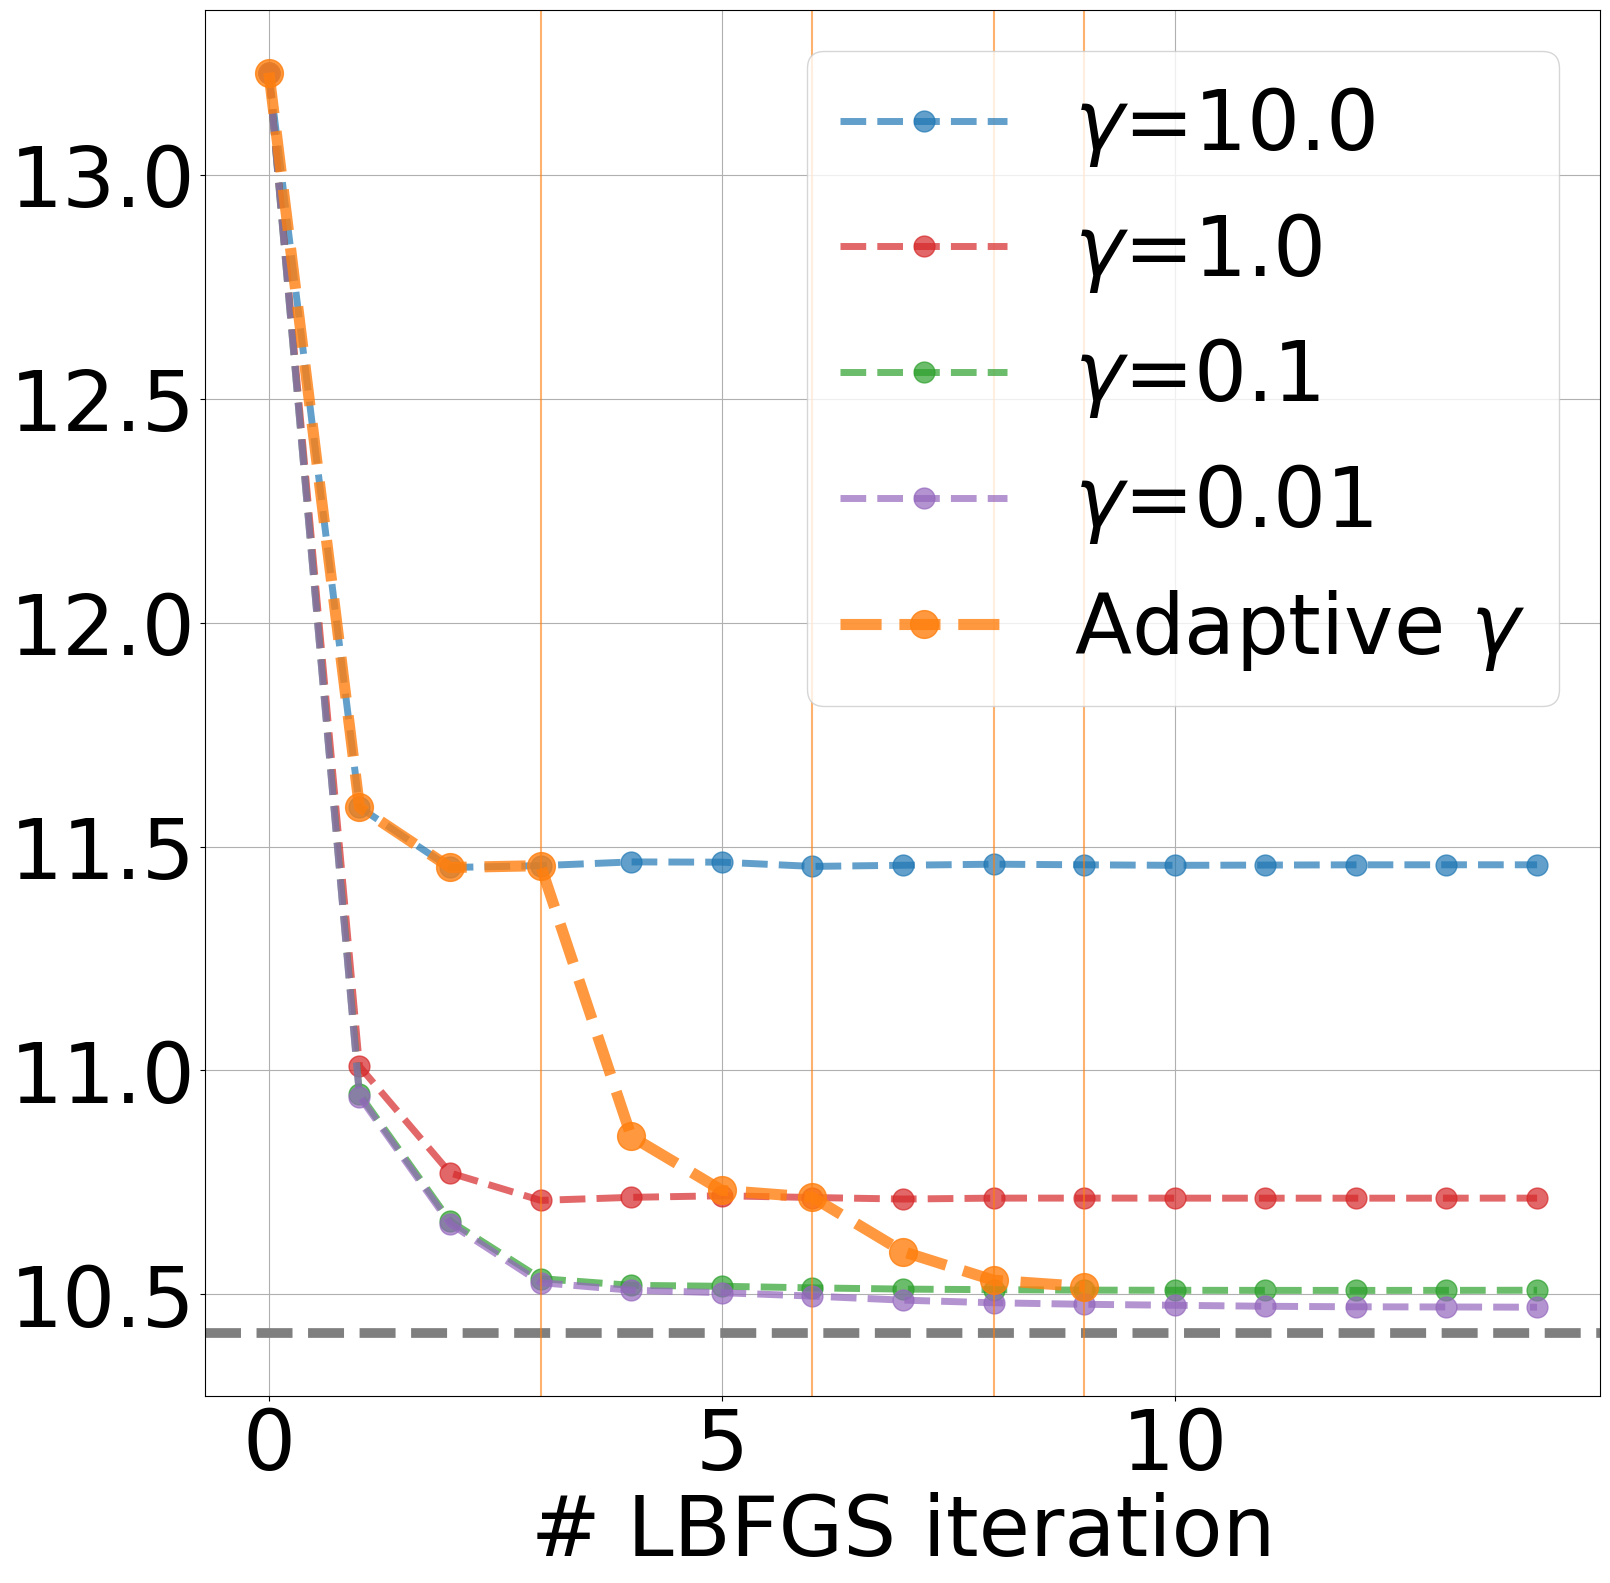

In [113]:
# plot result of our method:
plt.figure(figsize=(18,18))

plt.axhline(y = val_opt_loss, linestyle='--', linewidth=7, color='tab:grey')

for i in range(len(val_losses)):
    plt.plot(np.arange(len(val_losses[i])), val_losses[i], '--o', color=colors[i], linewidth=5, markersize=15, alpha=0.7, label=f'$\gamma$={math.pow(10,1-i)}')

plt.plot(np.arange(len(adaptive_val_loss)), adaptive_val_loss, '--o', color='tab:orange', linewidth=8, markersize=20, alpha=0.8, label=f'Adaptive $\gamma$')
for break_itr in breaks:
    plt.axvline(x = break_itr, color='tab:orange', alpha=0.6, zorder=2)
    
mpl.rcParams['font.size'] = 60

font_size = 60


# plt.ylim(2.5, 3)

plt.xlabel(f'# LBFGS iteration', fontsize=font_size)
# plt.ylabel(f"$\\theta_i^*(\\lambda_2)$", fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
C:\Users\dongq\AppData\Local\Temp\ipykernel_21264\301500205.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(train_losses[i])), train_losses[i], '--o', linewidth=7, markersize=16, label=f'$\gamma$={math.pow(10,1-i)}')


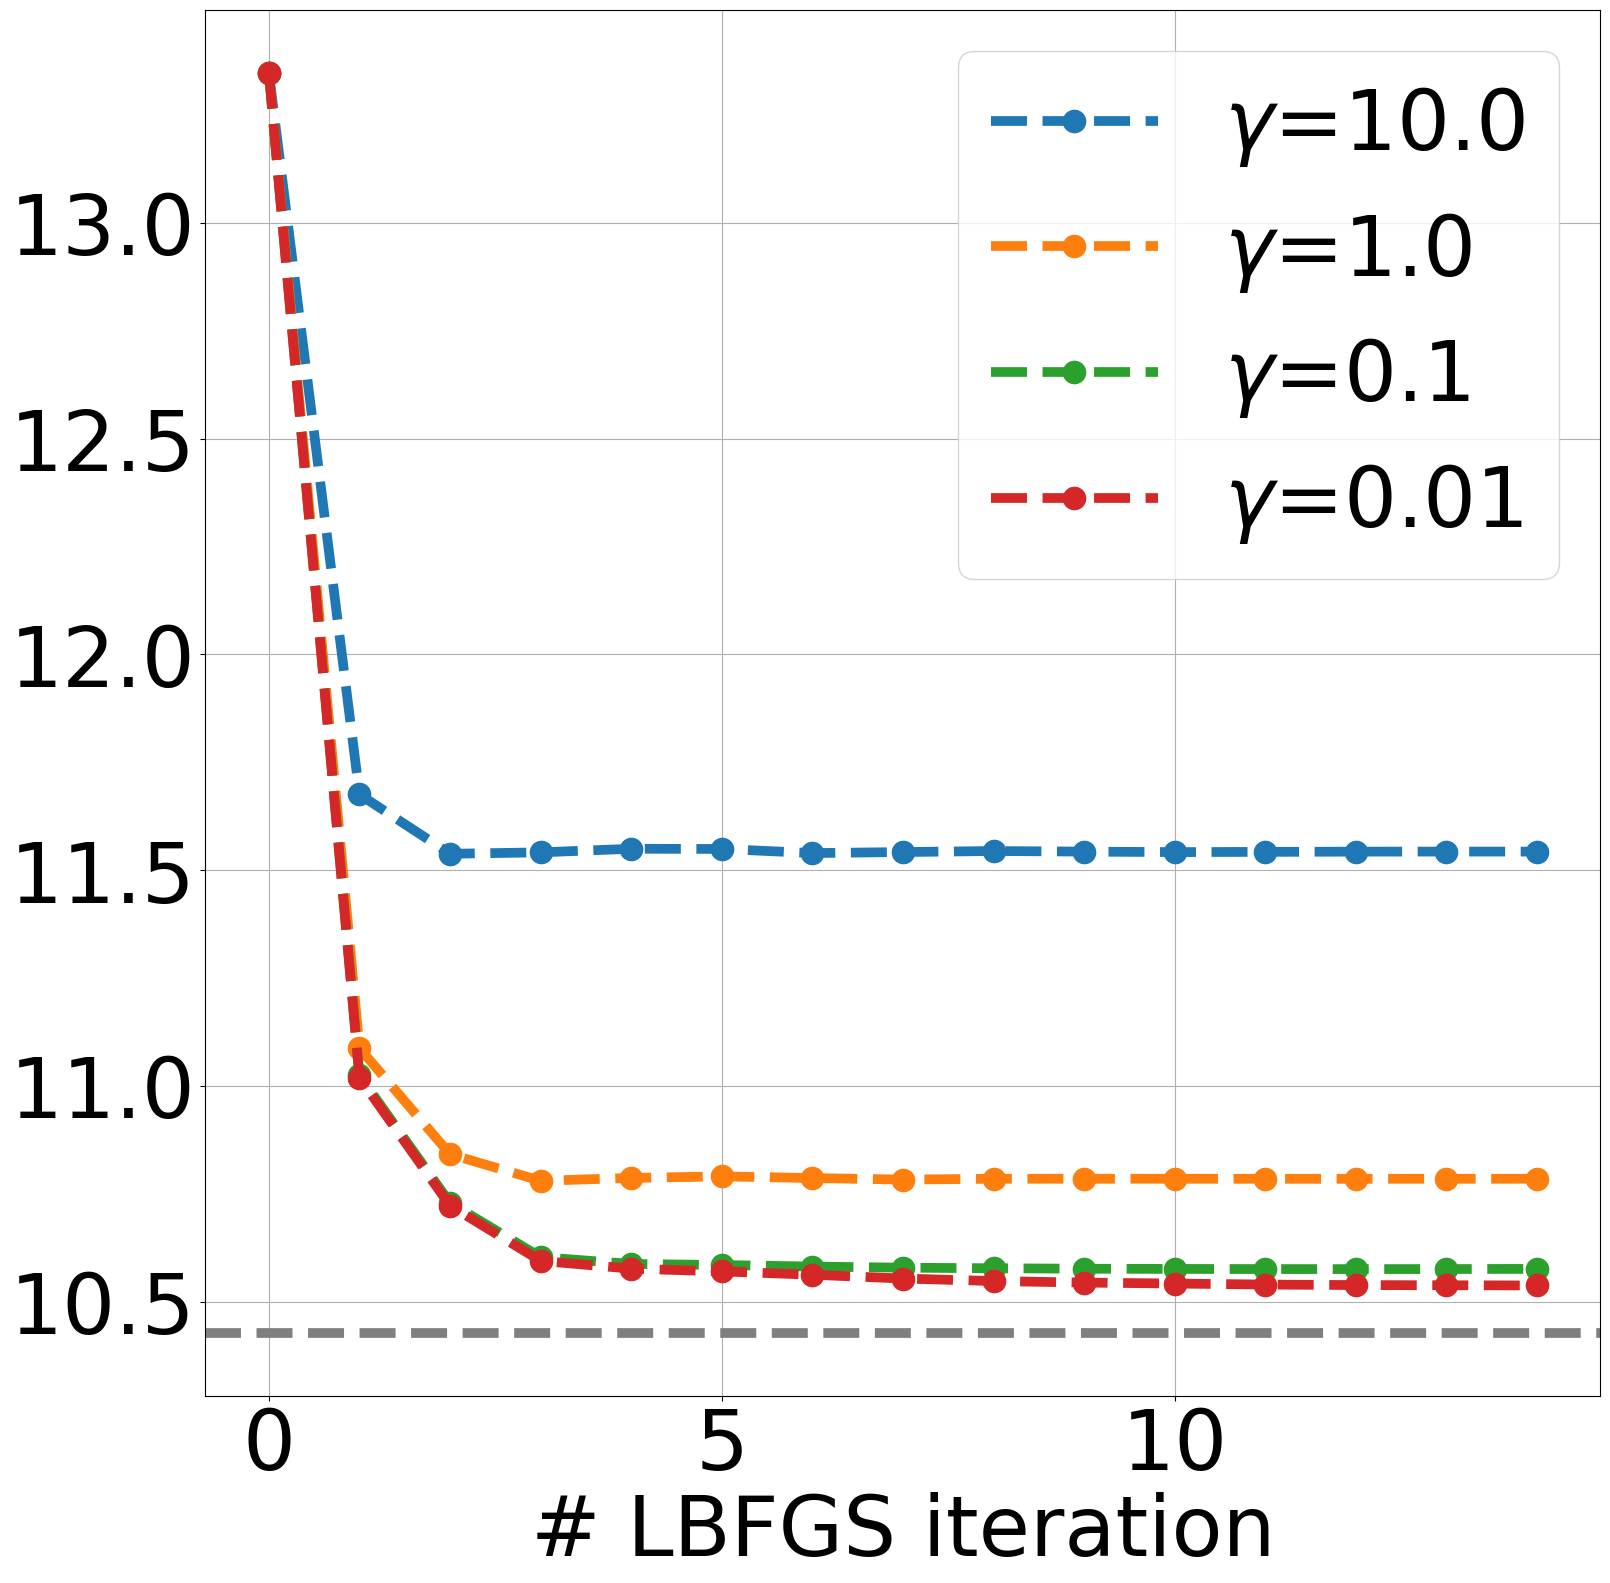

In [79]:
# plot result of our method:
plt.figure(figsize=(18,18))

plt.axhline(y = train_opt_loss, linestyle='--', linewidth=7, color='tab:grey')

for i in range(len(train_losses)):
    plt.plot(np.arange(len(train_losses[i])), train_losses[i], '--o', linewidth=7, markersize=16, label=f'$\gamma$={math.pow(10,1-i)}')
# Set global font size
mpl.rcParams['font.size'] = 60

font_size = 60

# plt.ylim(2.5, 3)

plt.xlabel(f'# LBFGS iteration', fontsize=font_size)
# plt.ylabel(f"$\\theta_i^*(\\lambda_2)$", fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
C:\Users\dongq\AppData\Local\Temp\ipykernel_21264\1126756921.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(np.arange(len(train_losses[i])), val_losses[i], '--o', linewidth=7, markersize=16, label=f'$\gamma$={math.pow(10,1-i)}')


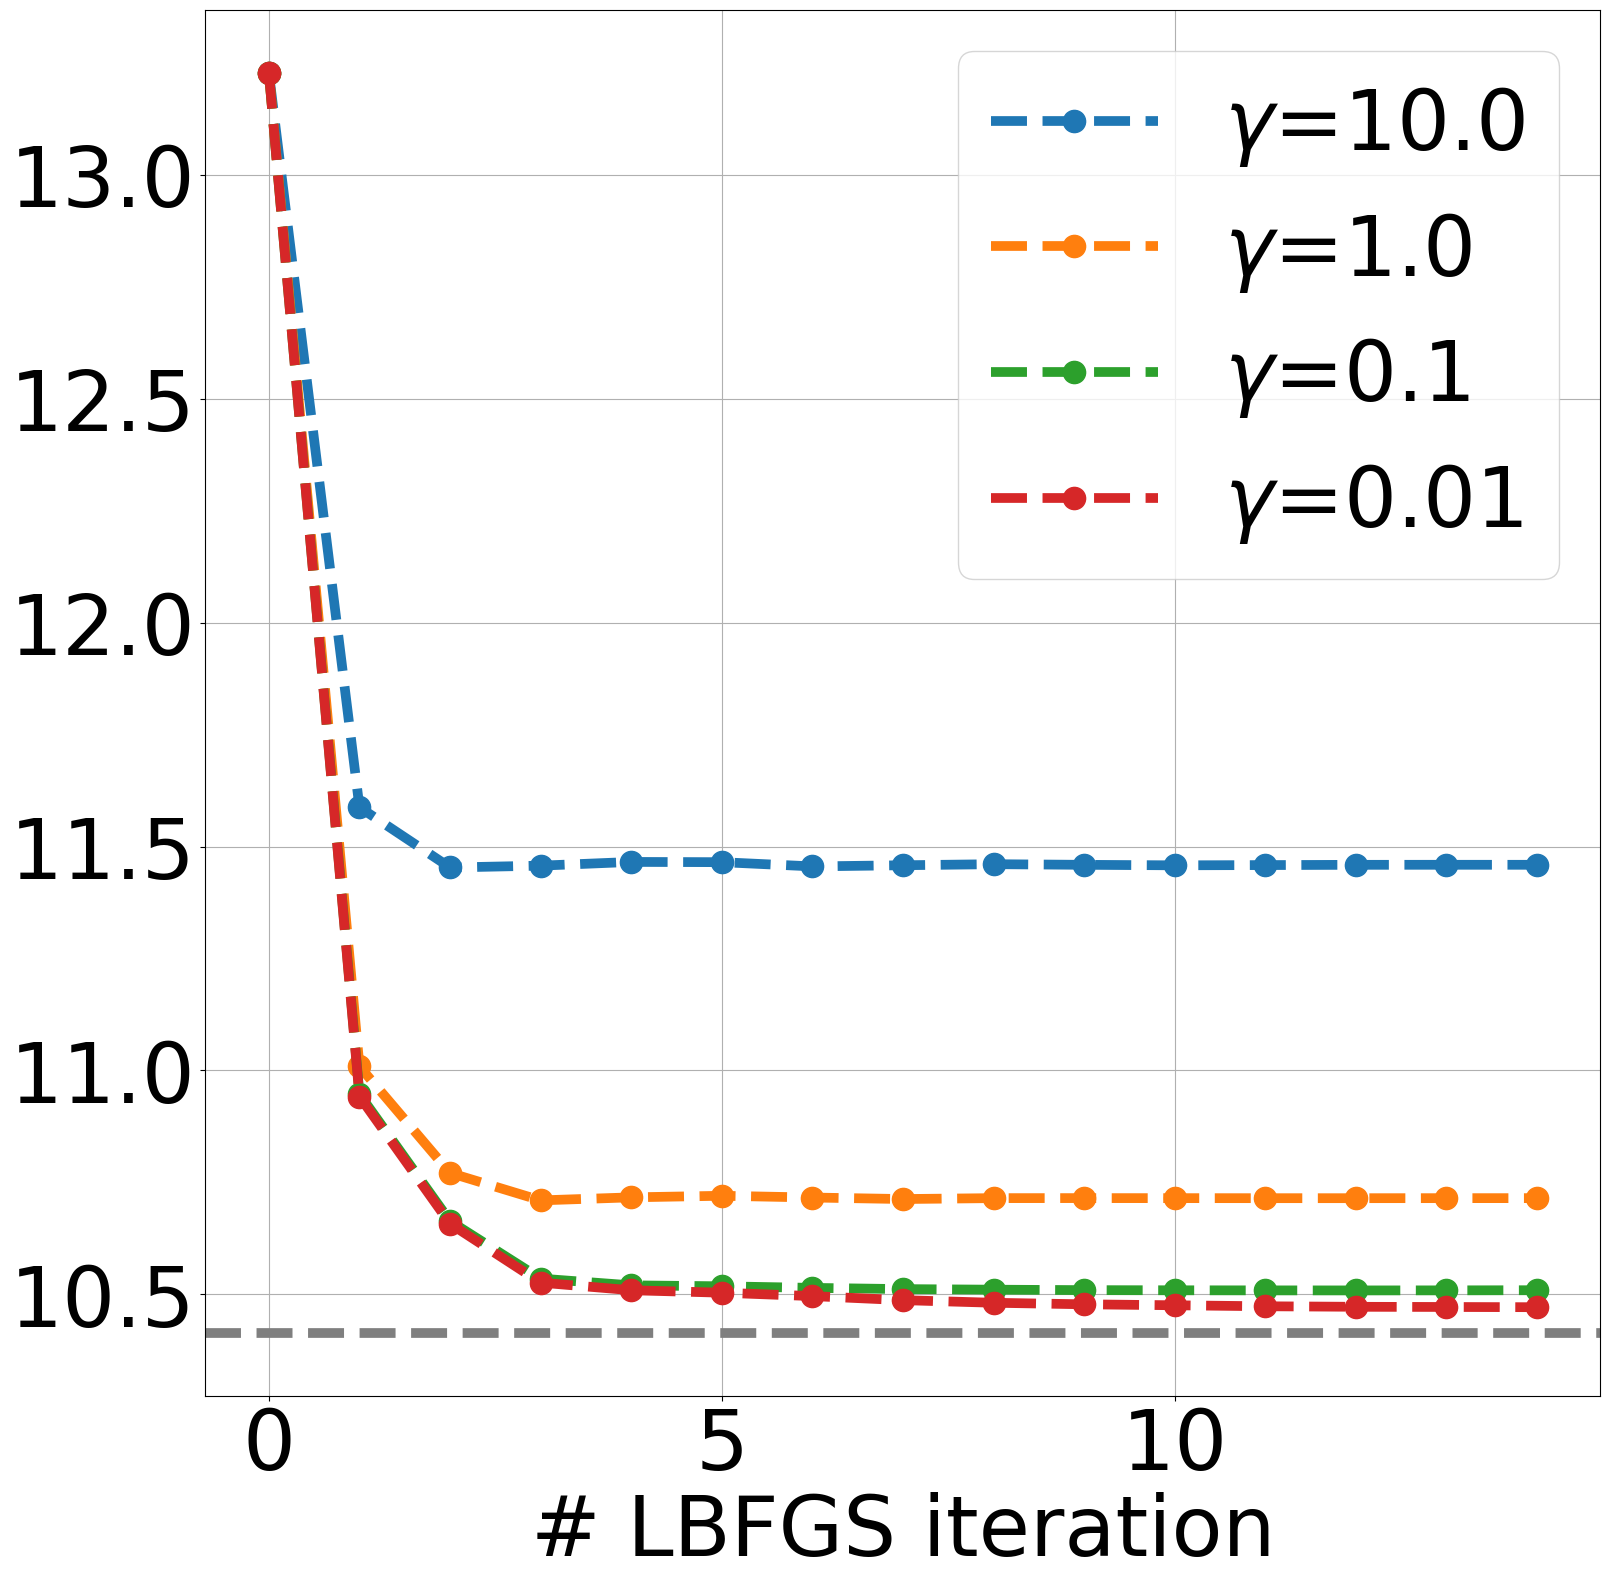

In [80]:
# plot result of our method:
plt.figure(figsize=(18,18))

plt.axhline(y = val_opt_loss, linestyle='--', linewidth=7, color='tab:grey')

for i in range(len(val_losses)):
    plt.plot(np.arange(len(train_losses[i])), val_losses[i], '--o', linewidth=7, markersize=16, label=f'$\gamma$={math.pow(10,1-i)}')
mpl.rcParams['font.size'] = 60

font_size = 60


# plt.ylim(2.5, 3)

plt.xlabel(f'# LBFGS iteration', fontsize=font_size)
# plt.ylabel(f"$\\theta_i^*(\\lambda_2)$", fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)